<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/An_Unsupervised_Machine_Learning_Framework_for_Clustering_Global_Electricity_Systems_Using_UMAP%2C_K_Means%2C_and_Hierarchical_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

import umap.umap_ as umap

# ==========================================
# Mount Google Drive
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("/content/drive/MyDrive/Dataset/global_electricity_comprehensive.csv")

print("Dataset Shape :", df.shape)

display(df.head())

Mounted at /content/drive
Dataset Shape : (2280, 24)


,Country,City,Year,Population,GDP_USD_Billion,Electricity_Consumption_TWh,Electricity_Generation_TWh,Installed_Capacity_GW,Peak_Demand_GW,Electricity_Per_Capita_kWh,...,Wind_Percentage,Nuclear_Percentage,Other_Renewable_Percentage,Oil_Other_Percentage,Renewable_Percentage,CO2_Emissions_MT,Transmission_Distribution_Loss_Pct,Avg_Electricity_Price_USD_per_kWh,Urbanization_Rate_Pct,Energy_Intensity_kWh_per_1000USD
0,Argentina,Buenos Aires,2016,2988021,123.91,16.715,13.104,3.22,3.75,5593.9,...,1.1,3.6,0.2,6.9,12.6,15.35,10.3,0.066,100.0,134.9
1,Argentina,Buenos Aires,2017,3029490,126.95,16.594,12.886,3.24,3.79,5477.5,...,1.5,3.5,0.4,5.5,12.6,25.60,10.1,0.060,100.0,130.7
2,Argentina,Buenos Aires,2018,3059701,130.27,16.826,13.463,3.27,3.94,5499.2,...,2.0,3.4,0.6,10.4,13.3,0.01,10.5,0.066,100.0,129.2
3,Argentina,Buenos Aires,2019,3094105,133.21,17.078,14.148,3.32,3.98,5519.4,...,2.3,3.5,0.8,7.2,15.1,22.48,11.9,0.072,100.0,128.2
4,Argentina,Buenos Aires,2020,3094141,129.76,17.828,13.680,3.35,4.04,5761.8,...,2.9,3.4,1.0,6.2,16.8,0.01,12.9,0.067,100.0,137.4


In [2]:
# ==========================================
# Dataset Information
# ==========================================

df.info()

print("\nSummary Statistics\n")
display(df.describe())

print("\nMissing Values\n")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2280 entries, 0 to 2279
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Country                             2280 non-null   object 
 1   City                                2280 non-null   object 
 2   Year                                2280 non-null   int64  
 3   Population                          2280 non-null   int64  
 4   GDP_USD_Billion                     2280 non-null   float64
 5   Electricity_Consumption_TWh         2280 non-null   float64
 6   Electricity_Generation_TWh          2280 non-null   float64
 7   Installed_Capacity_GW               2280 non-null   float64
 8   Peak_Demand_GW                      2280 non-null   float64
 9   Electricity_Per_Capita_kWh          2280 non-null   float64
 10  Coal_Percentage                     2280 non-null   float64
 11  Gas_Percentage                      2280 no

,Year,Population,GDP_USD_Billion,Electricity_Consumption_TWh,Electricity_Generation_TWh,Installed_Capacity_GW,Peak_Demand_GW,Electricity_Per_Capita_kWh,Coal_Percentage,Gas_Percentage,...,Wind_Percentage,Nuclear_Percentage,Other_Renewable_Percentage,Oil_Other_Percentage,Renewable_Percentage,CO2_Emissions_MT,Transmission_Distribution_Loss_Pct,Avg_Electricity_Price_USD_per_kWh,Urbanization_Rate_Pct,Energy_Intensity_kWh_per_1000USD
count,2280.000000,2.280000e+03,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,...,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000
mean,2020.500000,3.048795e+07,437.518180,123.028980,123.587685,33.838079,20.134057,7552.940088,14.138684,32.649035,...,3.871447,8.232149,8.390307,16.968596,28.009430,150.105272,7.869386,0.148218,81.473991,279.774386
std,2.872911,1.364075e+08,1798.694802,604.172876,621.390342,174.046728,96.015074,6463.978586,17.356778,26.859145,...,6.440015,13.789091,8.097069,15.024711,19.462898,795.274707,4.681707,0.085418,20.169443,243.966918
min,2016.000000,1.185830e+05,1.480000,0.245000,0.192000,0.060000,0.050000,93.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.010000,1.500000,0.013000,20.500000,30.400000
25%,2018.000000,9.678895e+05,24.330000,5.882750,4.597500,1.050000,1.060000,2761.550000,1.000000,11.100000,...,0.300000,0.000000,2.200000,0.300000,14.475000,3.070000,4.700000,0.077000,69.900000,125.375000
50%,2020.500000,2.922258e+06,83.170000,13.597500,10.850000,2.450000,2.390000,6135.200000,5.500000,23.450000,...,1.800000,0.000000,6.800000,14.600000,23.200000,12.675000,6.400000,0.134500,88.000000,218.150000
75%,2023.000000,1.072136e+07,258.470000,50.800000,43.588000,10.860000,9.135000,10416.250000,24.000000,50.925000,...,4.525000,11.425000,11.900000,30.700000,37.100000,46.400000,9.700000,0.209000,100.000000,350.200000
max,2025.000000,1.441928e+09,23151.250000,9584.970000,9731.250000,2438.320000,1383.270000,51611.700000,95.700000,98.800000,...,63.900000,68.300000,53.700000,53.400000,100.000000,10916.400000,30.600000,0.442000,100.000000,2035.900000



Missing Values

Country                               0
City                                  0
Year                                  0
Population                            0
GDP_USD_Billion                       0
Electricity_Consumption_TWh           0
Electricity_Generation_TWh            0
Installed_Capacity_GW                 0
Peak_Demand_GW                        0
Electricity_Per_Capita_kWh            0
Coal_Percentage                       0
Gas_Percentage                        0
Hydro_Percentage                      0
Solar_Percentage                      0
Wind_Percentage                       0
Nuclear_Percentage                    0
Other_Renewable_Percentage            0
Oil_Other_Percentage                  0
Renewable_Percentage                  0
CO2_Emissions_MT                      0
Transmission_Distribution_Loss_Pct    0
Avg_Electricity_Price_USD_per_kWh     0
Urbanization_Rate_Pct                 0
Energy_Intensity_kWh_per_1000USD      0
dtype: int64


In [3]:
# ==========================================
# Keep Only Numerical Features
# ==========================================

X = df.select_dtypes(include=np.number)

print(X.columns)
print("Number of Numerical Features :", X.shape[1])

Index(['Year', 'Population', 'GDP_USD_Billion', 'Electricity_Consumption_TWh',
       'Electricity_Generation_TWh', 'Installed_Capacity_GW', 'Peak_Demand_GW',
       'Electricity_Per_Capita_kWh', 'Coal_Percentage', 'Gas_Percentage',
       'Hydro_Percentage', 'Solar_Percentage', 'Wind_Percentage',
       'Nuclear_Percentage', 'Other_Renewable_Percentage',
       'Oil_Other_Percentage', 'Renewable_Percentage', 'CO2_Emissions_MT',
       'Transmission_Distribution_Loss_Pct',
       'Avg_Electricity_Price_USD_per_kWh', 'Urbanization_Rate_Pct',
       'Energy_Intensity_kWh_per_1000USD'],
      dtype='object')
Number of Numerical Features : 22


In [4]:
# ==========================================
# Standardization
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [5]:
# ==========================================
# UMAP Embedding
# ==========================================

embedding = umap.UMAP(
    n_neighbors=15,
    min_dist=0.0,
    random_state=42
).fit_transform(X_scaled)

print("Embedding Shape :", embedding.shape)

Embedding Shape : (2280, 2)


In [6]:
# ==========================================
# Find Best k using Silhouette Score
# ==========================================

scores = {}

for k in range(2,9):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(embedding)

    scores[k] = silhouette_score(embedding, labels)

best_k = max(scores, key=scores.get)

print("Silhouette Scores")

for k,v in scores.items():
    print(f"{k} Clusters : {v:.4f}")

print("\nBest Number of Clusters =", best_k)

Silhouette Scores
2 Clusters : 0.3480
3 Clusters : 0.3925
4 Clusters : 0.3906
5 Clusters : 0.4001
6 Clusters : 0.4459
7 Clusters : 0.4430
8 Clusters : 0.4338

Best Number of Clusters = 6


In [7]:
# ==========================================
# Clustering Models
# ==========================================

models = {

    "K-Means":
        KMeans(
            n_clusters=best_k,
            random_state=42,
            n_init=10
        ),

    "Hierarchical":
        AgglomerativeClustering(
            n_clusters=best_k,
            linkage="ward"
        )

}

labels = {}

for name, model in models.items():
    labels[name] = model.fit_predict(embedding)

In [8]:
# ==========================================
# Evaluation Function
# ==========================================

def evaluate(cluster_labels):

    return {

        "Silhouette Score":
            silhouette_score(embedding, cluster_labels),

        "Calinski-Harabasz":
            calinski_harabasz_score(embedding, cluster_labels),

        "Davies-Bouldin":
            davies_bouldin_score(embedding, cluster_labels)

    }


results = pd.DataFrame({
    name: evaluate(label)
    for name, label in labels.items()
}).T.round(4)

print(results)

              Silhouette Score  Calinski-Harabasz  Davies-Bouldin
K-Means                 0.4459          2106.6355          0.7474
Hierarchical            0.3451          1576.0320          0.7973


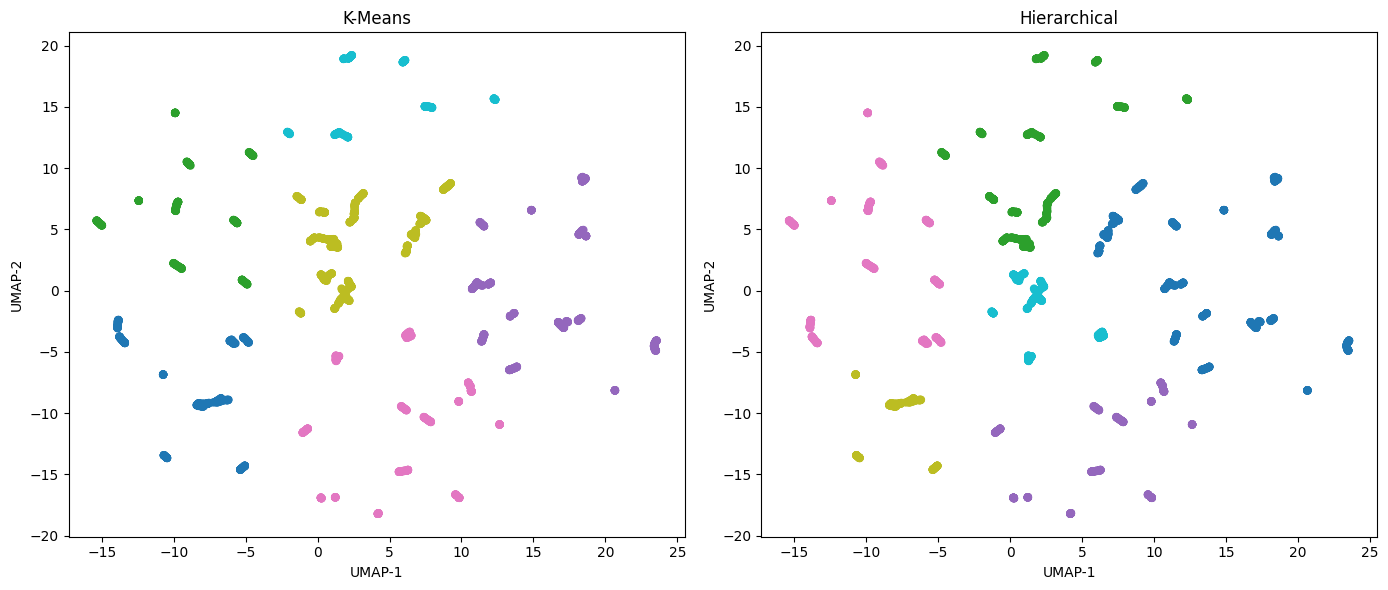

In [9]:
# ==========================================
# Cluster Visualization
# ==========================================

fig, axes = plt.subplots(1,2,figsize=(14,6))

for ax, (name, cluster) in zip(axes, labels.items()):

    scatter = ax.scatter(
        embedding[:,0],
        embedding[:,1],
        c=cluster,
        cmap='tab10',
        s=25
    )

    ax.set_title(name)
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")

plt.tight_layout()
plt.show()

In [10]:
df_cluster = df.copy()

df_cluster["Cluster"] = labels["K-Means"]

cluster_profile = df_cluster.groupby("Cluster").mean(numeric_only=True)

cluster_profile

,Year,Population,GDP_USD_Billion,Electricity_Consumption_TWh,Electricity_Generation_TWh,Installed_Capacity_GW,Peak_Demand_GW,Electricity_Per_Capita_kWh,Coal_Percentage,Gas_Percentage,...,Wind_Percentage,Nuclear_Percentage,Other_Renewable_Percentage,Oil_Other_Percentage,Renewable_Percentage,CO2_Emissions_MT,Transmission_Distribution_Loss_Pct,Avg_Electricity_Price_USD_per_kWh,Urbanization_Rate_Pct,Energy_Intensity_kWh_per_1000USD
Cluster,,,,,,,,,,,,,,,,,,,,,
0,2020.5,1.565229e+07,156.571486,61.951843,60.484554,13.769657,9.942229,8376.783143,3.916571,51.430857,...,0.989714,2.488571,8.219714,15.737714,26.426286,79.435514,7.764571,0.110249,85.842000,289.641714
1,2020.5,5.913269e+07,859.581839,354.790677,351.361681,95.457258,56.619516,8111.010645,14.419355,36.422903,...,2.398065,5.561935,6.748710,21.668387,21.931613,449.109065,6.360968,0.120474,83.344516,334.283226
2,2020.5,5.632061e+07,689.838659,169.280843,176.399984,48.042682,28.509886,4223.479773,27.378409,24.947727,...,1.549091,8.219773,6.496591,19.662955,19.788409,204.238591,11.080909,0.098850,67.765000,315.129091
3,2020.5,1.368390e+07,232.232737,39.206279,37.629932,10.209711,6.430105,11212.329737,3.796842,16.958421,...,4.772368,16.589737,9.452368,21.008421,41.638947,30.655447,7.647632,0.210529,83.280789,142.101316
4,2020.5,2.456348e+07,390.734400,84.473202,85.009385,25.779883,13.904383,6079.455333,18.213167,40.309000,...,6.702500,2.210833,9.192500,9.723833,29.541833,115.317117,7.207167,0.164505,84.236500,291.880833
5,2020.5,4.920289e+06,250.264850,43.859705,43.836045,11.266450,7.717000,10038.632000,9.891000,17.706500,...,6.102500,24.634000,10.975000,19.969000,27.793500,22.547300,5.733500,0.199025,89.370000,325.497000


| Cluster | Suggested Interpretation                       |
| ------- | ---------------------------------------------- |
| **0**   | Natural Gas-Based Developing Economies         |
| **1**   | High-Demand Industrial Economies               |
| **2**   | Coal-Dependent Emerging Economies              |
| **3**   | Renewable and Nuclear-Based Advanced Economies |
| **4**   | Balanced Energy Portfolio Economies            |
| **5**   | Efficient Small Advanced Economies             |
